In [ ]:
# Author: Mohammed Yasin
# GitHub: https://github.com/Y-T-G

In [ ]:
!pip install ultralytics

In [1]:
from ultralytics import YOLO, ASSETS
from ultralytics.utils.ops import xywh2xyxy, scale_boxes
from ultralytics.engine.results import Results
import torch
import time
from torch.nn.functional import cosine_similarity
import cv2
import matplotlib.pyplot as plt
from math import gcd
import numpy as np
from pathlib import Path

In [2]:
from types import MethodType

In [3]:
# Custom NMS to return the idxs of filtered boxes
def non_max_suppression(
    prediction,
    conf_thres=0.25,
    iou_thres=0.45,
    classes=None,
    agnostic=False,
    multi_label=False,
    labels=(),
    max_det=300,
    nc=0,  # number of classes (optional)
    max_time_img=0.05,
    max_nms=30000,
    max_wh=7680,
    in_place=True,
    rotated=False,
):
    """
    Perform non-maximum suppression (NMS) on a set of boxes, with support for masks and multiple labels per box.

    Args:
        prediction (torch.Tensor): A tensor of shape (batch_size, num_classes + 4 + num_masks, num_boxes)
            containing the predicted boxes, classes, and masks. The tensor should be in the format
            output by a model, such as YOLO.
        conf_thres (float): The confidence threshold below which boxes will be filtered out.
            Valid values are between 0.0 and 1.0.
        iou_thres (float): The IoU threshold below which boxes will be filtered out during NMS.
            Valid values are between 0.0 and 1.0.
        classes (List[int]): A list of class indices to consider. If None, all classes will be considered.
        agnostic (bool): If True, the model is agnostic to the number of classes, and all
            classes will be considered as one.
        multi_label (bool): If True, each box may have multiple labels.
        labels (List[List[Union[int, float, torch.Tensor]]]): A list of lists, where each inner
            list contains the apriori labels for a given image. The list should be in the format
            output by a dataloader, with each label being a tuple of (class_index, x1, y1, x2, y2).
        max_det (int): The maximum number of boxes to keep after NMS.
        nc (int, optional): The number of classes output by the model. Any indices after this will be considered masks.
        max_time_img (float): The maximum time (seconds) for processing one image.
        max_nms (int): The maximum number of boxes into torchvision.ops.nms().
        max_wh (int): The maximum box width and height in pixels.
        in_place (bool): If True, the input prediction tensor will be modified in place.
        rotated (bool): If Oriented Bounding Boxes (OBB) are being passed for NMS.

    Returns:
        (List[torch.Tensor]): A list of length batch_size, where each element is a tensor of
            shape (num_boxes, 6 + num_masks) containing the kept boxes, with columns
            (x1, y1, x2, y2, confidence, class, mask1, mask2, ...).
    """
    import torchvision  # scope for faster 'import ultralytics'

    # Checks
    assert 0 <= conf_thres <= 1, f"Invalid Confidence threshold {conf_thres}, valid values are between 0.0 and 1.0"
    assert 0 <= iou_thres <= 1, f"Invalid IoU {iou_thres}, valid values are between 0.0 and 1.0"
    if isinstance(prediction, (list, tuple)):  # YOLOv8 model in validation model, output = (inference_out, loss_out)
        prediction = prediction[0]  # select only inference output
    if classes is not None:
        classes = torch.tensor(classes, device=prediction.device)

    if prediction.shape[-1] == 6:  # end-to-end model (BNC, i.e. 1,300,6)
        output = [pred[pred[:, 4] > conf_thres][:max_det] for pred in prediction]
        if classes is not None:
            output = [pred[(pred[:, 5:6] == classes).any(1)] for pred in output]
        return output

    bs = prediction.shape[0]  # batch size (BCN, i.e. 1,84,6300)
    nc = nc or (prediction.shape[1] - 4)  # number of classes
    nm = prediction.shape[1] - nc - 4  # number of masks
    mi = 4 + nc  # mask start index
    xc = prediction[:, 4:mi].amax(1) > conf_thres  # candidates

    # To keep track of the prediction indices that remain at the end, we create an indices
    # list that will be applied the same filters that get applied to the original predictions.
    # That way, at the end, we will have xks with only the indices of the predictions that
    # have not been eliminated.
    xinds = torch.stack([torch.arange(len(i), device=prediction.device) for i in xc])[...,None]
    # Settings
    # min_wh = 2  # (pixels) minimum box width and height
    time_limit = 2.0 + max_time_img * bs  # seconds to quit after
    multi_label &= nc > 1  # multiple labels per box (adds 0.5ms/img)

    prediction = prediction.transpose(-1, -2)  # shape(1,84,6300) to shape(1,6300,84)
    if not rotated:
        if in_place:
            prediction[..., :4] = xywh2xyxy(prediction[..., :4])  # xywh to xyxy
        else:
            prediction = torch.cat((xywh2xyxy(prediction[..., :4]), prediction[..., 4:]), dim=-1)  # xywh to xyxy

    t = time.time()
    output = [torch.zeros((0, 6 + nm), device=prediction.device)] * bs
    feati = [torch.zeros((0, 1), device=prediction.device)] * bs
    for xi, (x, xk) in enumerate(zip(prediction, xinds)):  # image index, image inference
        # Apply constraints
        # x[((x[:, 2:4] < min_wh) | (x[:, 2:4] > max_wh)).any(1), 4] = 0  # width-height
        filt = xc[xi]
        x = x[filt]  # confidence
        xk = xk[filt] # indices update

        # Cat apriori labels if autolabelling
        if labels and len(labels[xi]) and not rotated:
            lb = labels[xi]
            v = torch.zeros((len(lb), nc + nm + 4), device=x.device)
            v[:, :4] = xywh2xyxy(lb[:, 1:5])  # box
            v[range(len(lb)), lb[:, 0].long() + 4] = 1.0  # cls
            x = torch.cat((x, v), 0)

        # If none remain process next image
        if not x.shape[0]:
            continue

        # Detections matrix nx6 (xyxy, conf, cls)
        box, cls, mask = x.split((4, nc, nm), 1)

        if multi_label:
            i, j = torch.where(cls > conf_thres)
            x = torch.cat((box[i], x[i, 4 + j, None], j[:, None].float(), mask[i]), 1)
            xk = xk[i] # indices update
        else:  # best class only
            conf, j = cls.max(1, keepdim=True)
            filt = conf.view(-1) > conf_thres
            x = torch.cat((box, conf, j.float(), mask), 1)[filt]
            xk = xk[filt] # indices update

        # Filter by class
        if classes is not None:
            filt = (x[:, 5:6] == classes).any(1)
            x = x[filt]
            xk = xk[filt] # indices update

        # Check shape
        n = x.shape[0]  # number of boxes
        if not n:  # no boxes
            continue
        if n > max_nms:  # excess boxes
            filt = x[:, 4].argsort(descending=True)[:max_nms]
            x = x[filt]  # sort by confidence and remove excess boxes
            xk = xk[filt] # indices update

        # Batched NMS
        c = x[:, 5:6] * (0 if agnostic else max_wh)  # classes
        scores = x[:, 4]  # scores
        if rotated:
            boxes = torch.cat((x[:, :2] + c, x[:, 2:4], x[:, -1:]), dim=-1)  # xywhr
            i = nms_rotated(boxes, scores, iou_thres)
        else:
            boxes = x[:, :4] + c  # boxes (offset by class)
            i = torchvision.ops.nms(boxes, scores, iou_thres)  # NMS
        i = i[:max_det]  # limit detections

        # # Experimental
        # merge = False  # use merge-NMS
        # if merge and (1 < n < 3E3):  # Merge NMS (boxes merged using weighted mean)
        #     # Update boxes as boxes(i,4) = weights(i,n) * boxes(n,4)
        #     from .metrics import box_iou
        #     iou = box_iou(boxes[i], boxes) > iou_thres  # IoU matrix
        #     weights = iou * scores[None]  # box weights
        #     x[i, :4] = torch.mm(weights, x[:, :4]).float() / weights.sum(1, keepdim=True)  # merged boxes
        #     redundant = True  # require redundant detections
        #     if redundant:
        #         i = i[iou.sum(1) > 1]  # require redundancy

        output[xi] = x[i]
        # xk would contain the indices of the predictions that are in x,
        # i.e. you could index the `prediction` variable at the beginning of this function
        # and get the final x (in xyxy format)
        feati[xi] = xk[i].reshape(-1)
        if (time.time() - t) > time_limit:
            print(f"WARNING ⚠️ NMS time limit {time_limit:.3f}s exceeded")
            break  # time limit exceeded
    return output, feati

In [4]:
model = YOLO("./ckpts/yolo12l.pt")

In [5]:
# Update the method so that feature maps are returned without any modifications
def _predict_once(self, x, profile=False, visualize=False, embed=None):
    y, dt, embeddings = [], [], []  # outputs
    for m in self.model:
        if m.f != -1:  # if not from previous layer
            x = y[m.f] if isinstance(m.f, int) else [x if j == -1 else y[j] for j in m.f]  # from earlier layers
        if profile:
            self._profile_one_layer(m, x, dt)
        x = m(x)  # run
        y.append(x if m.i in self.save else None)  # save output
        if visualize:
            feature_visualization(x, m.type, m.i, save_dir=visualize)

        # Change this so that it returns the feature maps without any change
        if embed and m.i in embed:
            embeddings.append(x)  # flatten
            if m.i == max(embed):
                return embeddings
    return x

# Monkey patch method
model.model._predict_once = MethodType(_predict_once, model.model)

In [6]:
# Find the FPN output layers
model.model.yaml

{'nc': 80,
 'scales': {'n': [0.5, 0.25, 1024],
  's': [0.5, 0.5, 1024],
  'm': [0.5, 1.0, 512],
  'l': [1.0, 1.0, 512],
  'x': [1.0, 1.5, 512]},
 'backbone': [[-1, 1, 'Conv', [64, 3, 2]],
  [-1, 1, 'Conv', [128, 3, 2]],
  [-1, 2, 'C3k2', [256, False, 0.25]],
  [-1, 1, 'Conv', [256, 3, 2]],
  [-1, 2, 'C3k2', [512, False, 0.25]],
  [-1, 1, 'Conv', [512, 3, 2]],
  [-1, 4, 'A2C2f', [512, True, 4]],
  [-1, 1, 'Conv', [1024, 3, 2]],
  [-1, 4, 'A2C2f', [1024, True, 1]]],
 'head': [[-1, 1, 'nn.Upsample', ['None', 2, 'nearest']],
  [[-1, 6], 1, 'Concat', [1]],
  [-1, 2, 'A2C2f', [512, False, -1]],
  [-1, 1, 'nn.Upsample', ['None', 2, 'nearest']],
  [[-1, 4], 1, 'Concat', [1]],
  [-1, 2, 'A2C2f', [256, False, -1]],
  [-1, 1, 'Conv', [256, 3, 2]],
  [[-1, 11], 1, 'Concat', [1]],
  [-1, 2, 'A2C2f', [512, False, -1]],
  [-1, 1, 'Conv', [512, 3, 2]],
  [[-1, 8], 1, 'Concat', [1]],
  [-1, 2, 'C3k2', [1024, True]],
  [[14, 17, 20], 1, 'Detect', ['nc']]],
 'scale': 'l',
 'yaml_file': 'yolov12l.yaml',
 

In [7]:
# Initialize predictor so that we can perform preprocess, inference and postprocess ourselves.
# 15, 18, 21 are the default FPN levels that are used by the head.
# We extract that along with the final output.
_ = model(ASSETS / "bus.jpg", save=False, embed=[14, 17, 20, 21])

In [8]:
# Run inference
imgs = [cv2.imread(ASSETS / "bus.jpg")]
prepped = model.predictor.preprocess(imgs)
result = model.predictor.inference(prepped)

In [11]:
result[0].shape, result[1].shape, result[2].shape, result[3][0].shape, result[3][1][0].shape, result[3][1][1].shape, result[3][1][2].shape

(torch.Size([1, 256, 80, 60]),
 torch.Size([1, 512, 40, 30]),
 torch.Size([1, 512, 20, 15]),
 torch.Size([1, 84, 6300]),
 torch.Size([1, 144, 80, 60]),
 torch.Size([1, 144, 40, 30]),
 torch.Size([1, 144, 20, 15]))

In [12]:
# This would return the NMS output in xywh format and the idxs of the predictions that were retained.
output, idxs = non_max_suppression(result[-1][0], in_place=False)

In [13]:
def get_object_features(feat_list, idxs):
    # feat_list would contain feature maps in grid format (N, C, H, W), where each (H,W) is an anchor location.
    # We permute and then flatten the grid so that each grid and its feature vectors
    # correspond with the indexes of the prediction. We also downsample the vector to the smallest one (64).
    s = gcd(*[x.shape[1] for x in feat_list]) # smallest vector length (64 for YOLOv8)
    obj_feats = torch.cat([x.permute(0, 2, 3, 1).reshape(x.shape[0], -1, s, x.shape[1] // s).mean(dim=-1) for x in feat_list], dim=1)
    return [feats[idx] for feats, idx in zip(obj_feats, idxs)] # for each image in batch, indexed separately

In [14]:
# Get features of every detected objected in the final output.
obj_feats = get_object_features(result[:3], idxs)

In [15]:
obj_feats = get_object_features(result[-1][1], idxs)

In [16]:
obj_feats[0].shape

torch.Size([6, 144])

In [50]:
# Similarity between first and second object
# The order corresponds to the order of boxes in results below
image_i = 0  # index of the image in batch
cosine_similarity(obj_feats[image_i][2], obj_feats[image_i][4], dim=0)

tensor(0.9786, device='cuda:0')

In [18]:
# Also turn the original inference output into results
output[image_i][:, :4] = scale_boxes(prepped.shape[2:], output[image_i][:, :4], imgs[image_i].shape)
result = Results(imgs[image_i], path="", names=model.predictor.model.names, boxes=output[image_i])

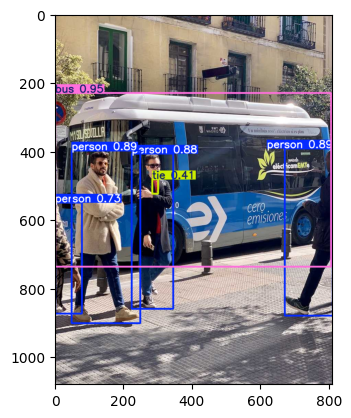

In [19]:
plt.imshow(result.plot()[...,::-1])

In [20]:
# Combined function
def get_result_with_features(imgs):
  # Run inference
  imgs = [cv2.imread(img) if isinstance(img, (str, Path)) else img for img in imgs]
  prepped = model.predictor.preprocess(imgs)
  result = model.predictor.inference(prepped)

  # This would return the NMS output in xywh format and the idxs of the predictions that were retained.
  outputs, idxs = non_max_suppression(result[-1][0], in_place=False)

  # Get features of every detected objected in the final output.
  obj_feats = get_object_features(result[:3], idxs)
  # obj_feats = get_object_features(result[-1][1], idxs)

  # Also turn the original inference output into results
  results = []
  for img, output, feat in zip(imgs, outputs, obj_feats):
      output[:, :4] = scale_boxes(prepped.shape[2:], output[:, :4], img.shape)
      result = Results(img, path="", names=model.predictor.model.names, boxes=output)
      result.feats = feat
      results.append(result)

  return results

results_with_feat = get_result_with_features([ASSETS / "bus.jpg"])

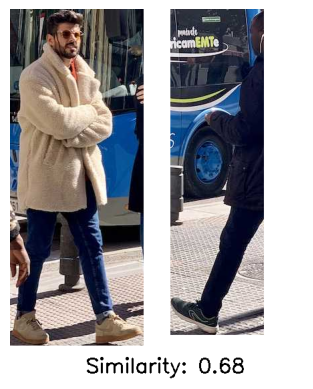

In [40]:
# You can now easily access the box along with the features of that particular box
result = results_with_feat[0] # for first image
img = imgs[0]
i, j = 1, 2
(box1, box2), (feat1, feat2) = result.boxes.xyxy[[i,j]], result.feats[[i,j]]

# Crop the box from the original image
x1, y1, x2, y2 = map(int, box1)
crop1 = img[y1:y2, x1:x2]

# Crop the box from the original image
x1, y1, x2, y2 = map(int, box2)
crop2 = img[y1:y2, x1:x2]

# Create a canvas to display the crops side-by-side
canvas = np.ones((max(crop1.shape[0], crop2.shape[0]) + 50, crop1.shape[1] + crop2.shape[1] + 100, 3), dtype=np.uint8) * 255
canvas[:crop1.shape[0], :crop1.shape[1]] = crop1
canvas[:crop2.shape[0], 100+crop2.shape[1]:100+crop2.shape[1]*2] = crop2

# Calculate similarity
similarity = cosine_similarity(feat1, feat2, dim=0).item()

# Put the similarity text on the canvas
cv2.putText(canvas, f'Similarity: {similarity:.2f}', ((crop1.shape[1] + crop2.shape[1]) // 3, crop1.shape[0] + 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

# Display the canvas
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Comparison with ResNet50

In [ ]:
import timm
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config
from PIL import Image
from torch.nn.functional import cosine_similarity
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

In [ ]:
timm_model = timm.create_model('resnet50', pretrained=True, features_only=True)
timm_model.eval()
timm_model.requires_grad_(False)
transform = create_transform(**resolve_data_config(timm_model.pretrained_cfg, model=timm_model))

In [ ]:
def compare_pairs(img, result, timm_model, transform, pairs):
    yolo_latencies, timm_latencies, similarities = [], [], []
    canvases = []
    last_box1, last_box2 = torch.zeros(4), torch.zeros(4)
    for pair in pairs:
        pair = list(pair)
        (box1, box2), (yolo_feat1, yolo_feat2) = result.boxes.xyxy[pair], result.feats[pair]

        # Crop boxes
        crop1 = img[int(box1[1]):int(box1[3]), int(box1[0]):int(box1[2])]
        crop2 = img[int(box2[1]):int(box2[3]), int(box2[0]):int(box2[2])]

        # TIMM embeddings
        st = time.perf_counter()
        timm_feat1 = timm_model(transform(Image.fromarray(crop1))[None]) if not torch.equal(box1, last_box1) else timm_feat1
        timm_feat2 = timm_model(transform(Image.fromarray(crop2))[None]) if not torch.equal(box2, last_box2) else timm_feat1
        timm_latency = time.perf_counter() - st

        last_box1, last_box2 = box1, box2

        timm_similarity = cosine_similarity(timm_feat1[-1].flatten(), timm_feat2[-1].flatten(), dim=-1).item()
        yolo_similarity = cosine_similarity(yolo_feat1.flatten(), yolo_feat2.flatten(), dim=-1).item()

        # Latency tracking
        yolo_latencies.append(None)  # YOLO already run before
        timm_latencies.append(timm_latency)
        similarities.append((yolo_similarity, timm_similarity))

        # Visualization
        h = max(crop1.shape[0], crop2.shape[0])
        w = crop1.shape[1] + crop2.shape[1]
        spacer = np.ones((h, 10, 3), dtype=np.uint8) * 255
        def pad_to_same_height(img1, img2):
            h1, w1, _ = img1.shape
            h2, w2, _ = img2.shape
            if h1 > h2:
                pad = np.ones((h1 - h2, w2, 3), dtype=np.uint8) * 255
                img2 = np.vstack([img2, pad])
            elif h2 > h1:
                pad = np.ones((h2 - h1, w1, 3), dtype=np.uint8) * 255
                img1 = np.vstack([img1, pad])
            return img1, img2
        crop1, crop2 = pad_to_same_height(crop1, crop2)
        combined_crop = np.hstack([crop1, spacer, crop2])

        text = f"YOLO: {yolo_similarity:.2f}, R50: {timm_similarity:.2f}"
        text_pos = (w // 4, h - 10)

        # Measure text size
        (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)

        # Draw background rectangle (darker, semi-transparent)
        bg_rect_start = (text_pos[0] - 5, text_pos[1] - text_h - 5)
        bg_rect_end = (text_pos[0] + text_w + 5, text_pos[1] + 5)
        cv2.rectangle(combined_crop, bg_rect_start, bg_rect_end, (0, 0, 0), -1, cv2.LINE_AA)

        # Overlay text on top
        cv2.putText(combined_crop, text, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

        canvases.append(combined_crop)

    # Display strip/mosaic
    def pad_to_same_width(imgs):
        max_w = max(img.shape[1] for img in imgs)
        padded_imgs = []
        for img in imgs:
            h, w, c = img.shape
            if w < max_w:
                pad = np.ones((h, max_w - w, c), dtype=np.uint8) * 255
                img = np.hstack([img, pad])
            padded_imgs.append(img)
        return padded_imgs

    canvases = pad_to_same_width(canvases)
    strip = np.vstack(canvases)

    plt.figure(figsize=(5, len(pairs) * 3))
    plt.imshow(cv2.cvtColor(strip, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"YOLO Latency: {yolo_latency * 1000:.1f}ms, R50 Latency: {np.sum(timm_latencies) * 1000:.1f}ms")
    plt.show()

    return similarities, timm_latencies

In [ ]:
img = cv2.imread("cars.jpg")
st = time.perf_counter()
results_with_feat = get_result_with_features([img])
yolo_latency = time.perf_counter() - st

result = results_with_feat[0]

pairs = list(combinations(range(len(result.boxes)), 2))[7:13]

compare_pairs(img, result, timm_model, transform, pairs)